Generate Data
(y = 3x+8 , e=5)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt


In [2]:
def generate_data(n_sample=50 , noise=0.5):
    np.random.seed(42)
    X = np.linspace(-10,10,n_sample)
    w1 = 3
    w0 = 8
    noise = np.random.rand(n_sample) * noise
    y = w1*X + w0 + noise
    return X , y

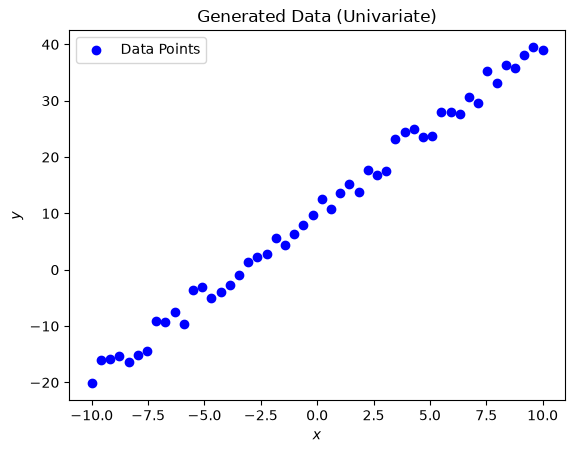

In [6]:
X , y = generate_data(50,5.0)
plt.scatter(X,y,color='blue',label='Data Points')
plt.title("Generated Data (Univariate)")
plt.xlabel("$x$")
plt.ylabel("$y$")
plt.legend()
plt.show()

Linear Regression: Analytical Solution

Implement the Closed-Form Solution
$$\mathbf{w} = (\mathbf{X}^T\mathbf{X})^{-1}\mathbf{X}^T\mathbf{y}$$

$$
y = w_0 + w_1 x
$$



$$
y = X_b w
$$

$$J(\mathbf{w}) = \sum_{i=1}^n \left(y^{(i)} - h_{\mathbf{w}}(x^{(i)})\right)^2 = \sum_{i=1}^n \left(y^{(i)} - \mathbf{w}^T\mathbf{x}^{(i)}\right)^2$$



$$\mathbf{X_b} = \begin{bmatrix} 1 & x_1^{(1)} & \cdots & x_d^{(1)} \\ 1 & x_1^{(2)} & \cdots & x_d^{(2)} \\ \vdots & \vdots & \ddots & \vdots \\ 1 & x_1^{(n)} & \cdots & x_d^{(n)} \end{bmatrix}, \quad \mathbf{w} = \begin{bmatrix} w_0 \\ w_1 \\ \vdots \\ w_d \end{bmatrix}, \quad \mathbf{y} = \begin{bmatrix} y^{(1)} \\ \vdots \\ y^{(n)} \end{bmatrix}$$

Proof:
$$J(\mathbf{w}) = \Vert{}\mathbf{y} - \mathbf{X_b}\mathbf{w}\Vert{}_2^2$$


$$\nabla_{\mathbf{w}} J(\mathbf{w}) = -2\mathbf{X_b}^T (\mathbf{y} - \mathbf{X_b}\mathbf{w})$$

Minimum:
$$\nabla_{\mathbf{w}} J(\mathbf{w}) = 0 \implies \mathbf{X_b}^T\mathbf{X}\mathbf{w} = \mathbf{X_b}^T\mathbf{y} \implies \mathbf{w} = (\mathbf{X_b}^T\mathbf{X_b})^{-1}\mathbf{X_b}^T\mathbf{y}$$

Final:
$$\mathbf{w} = (\mathbf{X_b}^T\mathbf{X_b})^{-1}\mathbf{X_b}^T\mathbf{y}$$

In [8]:
def h_w(x,w):
    return w[0] + w[1] * x

In [ ]:
def linear_regression_closed_form(X,y):
    X_b = np.c_[np.ones((len(X),1)) , X] ## y = Xb.W
    w = np.linalg.inv(X_b.T.dot(X_b)).dot(X_b.T).dot(y)
    return w

In [11]:
w = linear_regression_closed_form(X, y)
print(f"Parameters (w): ")
print(f"w_1 = {w[1]:.2f}, w_0 = {w[0]:.2f}")

Parameters (w): 
w_1 = 2.99, w_0 = 10.23


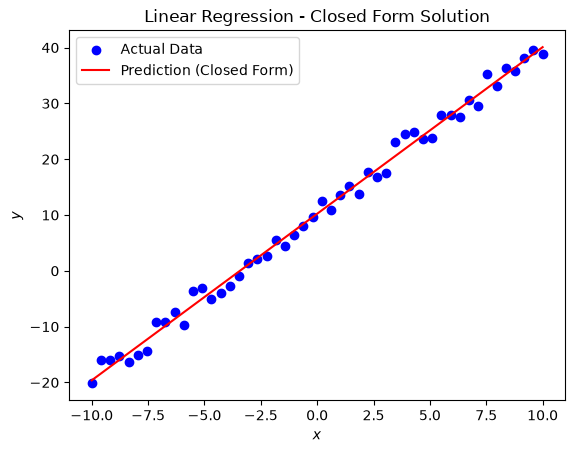

In [12]:
y_pred = h_w(X, w)

plt.scatter(X, y, color='blue', label='Actual Data')
plt.plot(X, y_pred, color='red', label='Prediction (Closed Form)')
plt.title("Linear Regression - Closed Form Solution")
plt.xlabel("$x$")
plt.ylabel("$y$")
plt.legend()
plt.show()